In [ ]:
# ============================================================
# PIPELINE 2: CNN DEEP FEATURES + SVM
# Indian Traditional Painting Classification
# ============================================================

import os
import json
import random
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from google.colab import files
import kagglehub

warnings.filterwarnings("ignore")

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# -----------------------------
# Device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

# -----------------------------
# Configuration
# -----------------------------
NUM_CLASSES_EXPECTED = 8
IMAGE_SIZE = 224
BATCH_SIZE = 64
NUM_WORKERS = 2

print("\nConfiguration:")
print("Seed:", SEED)
print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Expected classes:", NUM_CLASSES_EXPECTED)

Device: cuda
GPU: Tesla T4

Configuration:
Seed: 42
Image size: 224
Batch size: 64
Expected classes: 8


In [ ]:
# ============================================================
# DATASET DOWNLOAD
# ============================================================

dataset_path = kagglehub.dataset_download(
    "ajg117/indian-paintings-dataset"
)

print("Dataset path:")
print(dataset_path)

if not os.path.exists(dataset_path):
    raise FileNotFoundError(
        f"Dataset path does not exist: {dataset_path}"
    )

Using Colab cache for faster access to the 'indian-paintings-dataset' dataset.
Dataset path:
/kaggle/input/indian-paintings-dataset


In [ ]:
# ============================================================
# DATASET LOADING
# ============================================================

base_dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=None
)

class_names = base_dataset.classes
class_to_idx = base_dataset.class_to_idx

print("Number of images:", len(base_dataset))
print("Number of classes:", len(class_names))
print("\nClasses:")

for idx, class_name in enumerate(class_names):
    print(f"{idx}: {class_name}")

if len(class_names) != NUM_CLASSES_EXPECTED:
    raise ValueError(
        f"Expected {NUM_CLASSES_EXPECTED} classes, "
        f"but found {len(class_names)} classes."
    )

print("\nClass mapping:")
print(class_to_idx)

Number of images: 953
Number of classes: 8

Classes:
0: gond painting
1: kalighat painting
2: kangra painting
3: kerala mural
4: madhubani painting
5: mandana art drawing
6: pichwai painting
7: warli painting

Class mapping:
{'gond painting': 0, 'kalighat painting': 1, 'kangra painting': 2, 'kerala mural': 3, 'madhubani painting': 4, 'mandana art drawing': 5, 'pichwai painting': 6, 'warli painting': 7}


In [ ]:
# ============================================================
# EXACT 70/15/15 SPLIT
# random_split + seed 42
# ============================================================

total_size = len(base_dataset)

train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

generator = torch.Generator().manual_seed(SEED)

train_subset, val_subset, test_subset = torch.utils.data.random_split(
    base_dataset,
    [train_size, val_size, test_size],
    generator=generator
)

print("Total:", total_size)
print("Train:", len(train_subset))
print("Validation:", len(val_subset))
print("Test:", len(test_subset))

print("\nPercentages:")
print(f"Train: {len(train_subset) / total_size * 100:.2f}%")
print(f"Validation: {len(val_subset) / total_size * 100:.2f}%")
print(f"Test: {len(test_subset) / total_size * 100:.2f}%")

assert (
    len(train_subset)
    + len(val_subset)
    + len(test_subset)
    == total_size
)

assert len(train_subset) == train_size
assert len(val_subset) == val_size
assert len(test_subset) == test_size

Total: 953
Train: 667
Validation: 142
Test: 144

Percentages:
Train: 69.99%
Validation: 14.90%
Test: 15.11%


In [ ]:
# ============================================================
# DETERMINISTIC PREPROCESSING
# ============================================================

feature_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Create a transformed dataset using the SAME underlying
# ImageFolder ordering as the split above.
feature_dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=feature_transform
)

# Verify class ordering is identical.
if feature_dataset.classes != base_dataset.classes:
    raise RuntimeError(
        "Class ordering differs between datasets. "
        "Feature extraction cannot safely continue."
    )

# Reuse EXACT indices generated by random_split.
train_feature_dataset = Subset(
    feature_dataset,
    train_subset.indices
)

val_feature_dataset = Subset(
    feature_dataset,
    val_subset.indices
)

test_feature_dataset = Subset(
    feature_dataset,
    test_subset.indices
)

print("Deterministic feature datasets created.")

Deterministic feature datasets created.


In [ ]:
# ============================================================
# DATALOADERS
# ============================================================

train_loader = DataLoader(
    train_feature_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda")
)

val_loader = DataLoader(
    val_feature_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda")
)

test_loader = DataLoader(
    test_feature_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda")
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 11
Validation batches: 3
Test batches: 3


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

CHECKPOINT_PATH = "/content/drive/MyDrive/Iconography/Implementation/best_resnet50_indian_paintings.pth"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print(CHECKPOINT_PATH)

/content/drive/MyDrive/Iconography/Implementation/best_resnet50_indian_paintings.pth


In [ ]:
# ============================================================
# RESNET50 ARCHITECTURE
# ============================================================

resnet50 = models.resnet50(weights=None)

# The original baseline was configured for 8 classes.
resnet50.fc = nn.Linear(
    resnet50.fc.in_features,
    len(class_names)
)

print("ResNet50 classifier:")
print(resnet50.fc)

ResNet50 classifier:
Linear(in_features=2048, out_features=8, bias=True)


In [ ]:
# ============================================================
# LOAD TRAINED RESNET50 CHECKPOINT
# ============================================================

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location="cpu"
)

# ------------------------------------------------------------
# Handle common checkpoint formats
# ------------------------------------------------------------

if isinstance(checkpoint, dict):

    if "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]

    elif "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]

    elif "model" in checkpoint and isinstance(
        checkpoint["model"], dict
    ):
        state_dict = checkpoint["model"]

    else:
        # Could itself be a raw state_dict.
        state_dict = checkpoint

elif isinstance(checkpoint, nn.Module):
    state_dict = checkpoint.state_dict()

else:
    raise TypeError(
        "Unsupported checkpoint format. "
        "Expected a state_dict, checkpoint dictionary, "
        "or PyTorch model."
    )

# ------------------------------------------------------------
# Remove DataParallel "module." prefix if present
# ------------------------------------------------------------

clean_state_dict = {}

for key, value in state_dict.items():
    new_key = key

    if new_key.startswith("module."):
        new_key = new_key[len("module."):]

    clean_state_dict[new_key] = value

# ------------------------------------------------------------
# Load weights
# ------------------------------------------------------------

missing_keys, unexpected_keys = resnet50.load_state_dict(
    clean_state_dict,
    strict=False
)

print("Checkpoint loaded.")

if missing_keys:
    print("\nWARNING - Missing keys:")
    for key in missing_keys:
        print(key)

if unexpected_keys:
    print("\nWARNING - Unexpected keys:")
    for key in unexpected_keys:
        print(key)

# ------------------------------------------------------------
# Strong verification of final classifier
# ------------------------------------------------------------

expected_fc_weight_shape = (
    len(class_names),
    resnet50.fc.in_features
)

actual_fc_weight_shape = tuple(
    resnet50.fc.weight.shape
)

if actual_fc_weight_shape != expected_fc_weight_shape:
    raise RuntimeError(
        "The checkpoint/model classifier does not match "
        "the expected number of classes."
    )

print("\nFinal FC weight shape:", actual_fc_weight_shape)
print("Expected:", expected_fc_weight_shape)

Checkpoint loaded.

WARNING - Missing keys:
fc.weight
fc.bias

WARNING - Unexpected keys:
fc.1.weight
fc.1.bias

Final FC weight shape: (8, 2048)
Expected: (8, 2048)


In [ ]:
# ============================================================
# RESNET50 FEATURE EXTRACTOR
# ============================================================

FEATURE_DIM = 2048

feature_extractor = resnet50

# Replace the final classification layer.
feature_extractor.fc = nn.Identity()

feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

print("Final classification layer:", feature_extractor.fc)
print("Expected feature dimension:", FEATURE_DIM)

Final classification layer: Identity()
Expected feature dimension: 2048


In [ ]:
# ============================================================
# DEEP FEATURE EXTRACTION FUNCTION
# ============================================================

def extract_features(model, dataloader, device):
    """
    Extract fixed deep features from ResNet50.

    Returns:
        X: NumPy array of shape (N, 2048)
        y: NumPy array of shape (N,)
    """

    model.eval()

    feature_batches = []
    label_batches = []

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(
                device,
                non_blocking=True
            )

            features = model(images)

            # Safety check
            if features.ndim != 2:
                raise RuntimeError(
                    f"Expected 2-D feature tensor, "
                    f"got shape {tuple(features.shape)}"
                )

            if features.shape[1] != FEATURE_DIM:
                raise RuntimeError(
                    f"Expected {FEATURE_DIM}-D features, "
                    f"got {features.shape[1]}-D features."
                )

            feature_batches.append(
                features.cpu().numpy()
            )

            label_batches.append(
                labels.numpy()
            )

    if len(feature_batches) == 0:
        raise RuntimeError(
            "No features were extracted. "
            "The DataLoader may be empty."
        )

    X = np.concatenate(
        feature_batches,
        axis=0
    ).astype(np.float32)

    y = np.concatenate(
        label_batches,
        axis=0
    ).astype(np.int64)

    return X, y

In [ ]:
# ============================================================
# TRAINING FEATURES
# ============================================================

X_train, y_train = extract_features(
    feature_extractor,
    train_loader,
    device
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

assert X_train.shape == (
    len(train_feature_dataset),
    FEATURE_DIM
)

assert y_train.shape == (
    len(train_feature_dataset),
)

X_train shape: (667, 2048)
y_train shape: (667,)


In [ ]:
# ============================================================
# VALIDATION FEATURES
# ============================================================

X_val, y_val = extract_features(
    feature_extractor,
    val_loader,
    device
)

print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

assert X_val.shape == (
    len(val_feature_dataset),
    FEATURE_DIM
)

assert y_val.shape == (
    len(val_feature_dataset),
)

X_val shape: (142, 2048)
y_val shape: (142,)


In [ ]:
# ============================================================
# TEST FEATURES
# ============================================================

X_test, y_test = extract_features(
    feature_extractor,
    test_loader,
    device
)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

assert X_test.shape == (
    len(test_feature_dataset),
    FEATURE_DIM
)

assert y_test.shape == (
    len(test_feature_dataset),
)

X_test shape: (144, 2048)
y_test shape: (144,)


In [ ]:
# ============================================================
# FEATURE VERIFICATION
# ============================================================

print("========== FEATURE VERIFICATION ==========")

print("Training:")
print("  X:", X_train.shape)
print("  y:", y_train.shape)

print("\nValidation:")
print("  X:", X_val.shape)
print("  y:", y_val.shape)

print("\nTest:")
print("  X:", X_test.shape)
print("  y:", y_test.shape)

print("\nFeature dimension:", FEATURE_DIM)

# Verify labels are valid
all_labels = np.concatenate([
    y_train,
    y_val,
    y_test
])

if all_labels.min() < 0:
    raise ValueError("Negative class label detected.")

if all_labels.max() >= len(class_names):
    raise ValueError(
        "A label exceeds the available class indices."
    )

# Verify every split is non-empty
assert len(X_train) > 0
assert len(X_val) > 0
assert len(X_test) > 0

print("\nFeature extraction verification PASSED.")

========== FEATURE VERIFICATION ==========
Training:
  X: (667, 2048)
  y: (667,)

Validation:
  X: (142, 2048)
  y: (142,)

Test:
  X: (144, 2048)
  y: (144,)

Feature dimension: 2048

Feature extraction verification PASSED.


In [ ]:
# ============================================================
# TRAINING-ONLY FEATURE SCALING
# ============================================================

scaler_selection = StandardScaler()

X_train_scaled = scaler_selection.fit_transform(
    X_train
)

X_val_scaled = scaler_selection.transform(
    X_val
)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled validation shape:", X_val_scaled.shape)

assert X_train_scaled.shape == X_train.shape
assert X_val_scaled.shape == X_val.shape

Scaled training shape: (667, 2048)
Scaled validation shape: (142, 2048)


In [ ]:
# ============================================================
# SVM HYPERPARAMETER SEARCH
# ============================================================

C_VALUES = [0.1, 1, 10, 100]

RBF_GAMMA_VALUES = [
    "scale",
    0.001,
    0.01,
    0.1
]

print("Linear SVM C values:", C_VALUES)
print("RBF SVM C values:", C_VALUES)
print("RBF gamma values:", RBF_GAMMA_VALUES)

print(
    "\nTotal candidate models:",
    len(C_VALUES)
    + len(C_VALUES) * len(RBF_GAMMA_VALUES)
)

Linear SVM C values: [0.1, 1, 10, 100]
RBF SVM C values: [0.1, 1, 10, 100]
RBF gamma values: ['scale', 0.001, 0.01, 0.1]

Total candidate models: 20


In [ ]:
# ============================================================
# SVM MODEL SELECTION
# Primary metric: Validation Macro F1
# ============================================================

svm_results = []

best_model = None
best_params = None
best_macro_f1 = -np.inf

# ------------------------------------------------------------
# Linear SVM candidates
# ------------------------------------------------------------

for C in C_VALUES:

    print(f"Training Linear SVM | C={C}")

    model = SVC(
        kernel="linear",
        C=C
    )

    model.fit(
        X_train_scaled,
        y_train
    )

    val_predictions = model.predict(
        X_val_scaled
    )

    val_accuracy = accuracy_score(
        y_val,
        val_predictions
    )

    val_macro_precision = precision_score(
        y_val,
        val_predictions,
        average="macro",
        zero_division=0
    )

    val_macro_recall = recall_score(
        y_val,
        val_predictions,
        average="macro",
        zero_division=0
    )

    val_macro_f1 = f1_score(
        y_val,
        val_predictions,
        average="macro",
        zero_division=0
    )

    val_weighted_f1 = f1_score(
        y_val,
        val_predictions,
        average="weighted",
        zero_division=0
    )

    result = {
        "kernel": "linear",
        "C": C,
        "gamma": None,
        "val_accuracy": val_accuracy,
        "val_macro_precision": val_macro_precision,
        "val_macro_recall": val_macro_recall,
        "val_macro_f1": val_macro_f1,
        "val_weighted_f1": val_weighted_f1
    }

    svm_results.append(result)

    if val_macro_f1 > best_macro_f1:
        best_macro_f1 = val_macro_f1
        best_model = model
        best_params = {
            "kernel": "linear",
            "C": C,
            "gamma": None
        }

# ------------------------------------------------------------
# RBF SVM candidates
# ------------------------------------------------------------

for C in C_VALUES:

    for gamma in RBF_GAMMA_VALUES:

        print(
            f"Training RBF SVM | "
            f"C={C}, gamma={gamma}"
        )

        model = SVC(
            kernel="rbf",
            C=C,
            gamma=gamma
        )

        model.fit(
            X_train_scaled,
            y_train
        )

        val_predictions = model.predict(
            X_val_scaled
        )

        val_accuracy = accuracy_score(
            y_val,
            val_predictions
        )

        val_macro_precision = precision_score(
            y_val,
            val_predictions,
            average="macro",
            zero_division=0
        )

        val_macro_recall = recall_score(
            y_val,
            val_predictions,
            average="macro",
            zero_division=0
        )

        val_macro_f1 = f1_score(
            y_val,
            val_predictions,
            average="macro",
            zero_division=0
        )

        val_weighted_f1 = f1_score(
            y_val,
            val_predictions,
            average="weighted",
            zero_division=0
        )

        result = {
            "kernel": "rbf",
            "C": C,
            "gamma": gamma,
            "val_accuracy": val_accuracy,
            "val_macro_precision": val_macro_precision,
            "val_macro_recall": val_macro_recall,
            "val_macro_f1": val_macro_f1,
            "val_weighted_f1": val_weighted_f1
        }

        svm_results.append(result)

        if val_macro_f1 > best_macro_f1:
            best_macro_f1 = val_macro_f1
            best_model = model
            best_params = {
                "kernel": "rbf",
                "C": C,
                "gamma": gamma
            }

print("\nSVM selection completed.")

Training Linear SVM | C=0.1
Training Linear SVM | C=1
Training Linear SVM | C=10
Training Linear SVM | C=100
Training RBF SVM | C=0.1, gamma=scale
Training RBF SVM | C=0.1, gamma=0.001
Training RBF SVM | C=0.1, gamma=0.01
Training RBF SVM | C=0.1, gamma=0.1
Training RBF SVM | C=1, gamma=scale
Training RBF SVM | C=1, gamma=0.001
Training RBF SVM | C=1, gamma=0.01
Training RBF SVM | C=1, gamma=0.1
Training RBF SVM | C=10, gamma=scale
Training RBF SVM | C=10, gamma=0.001
Training RBF SVM | C=10, gamma=0.01
Training RBF SVM | C=10, gamma=0.1
Training RBF SVM | C=100, gamma=scale
Training RBF SVM | C=100, gamma=0.001
Training RBF SVM | C=100, gamma=0.01
Training RBF SVM | C=100, gamma=0.1

SVM selection completed.


In [ ]:
# ============================================================
# SVM VALIDATION RESULTS
# ============================================================

svm_results_df = pd.DataFrame(
    svm_results
)

svm_results_df = svm_results_df.sort_values(
    by=[
        "val_macro_f1",
        "val_accuracy"
    ],
    ascending=False
).reset_index(drop=True)

print("SVM candidates ranked by Validation Macro F1:\n")

display(svm_results_df)

print("\nBest configuration:")
print(best_params)

print(
    f"Best Validation Macro F1: "
    f"{best_macro_f1:.4f}"
)

SVM candidates ranked by Validation Macro F1:



,kernel,C,gamma,val_accuracy,val_macro_precision,val_macro_recall,val_macro_f1,val_weighted_f1
0,linear,0.1,None,0.816901,0.825140,0.810880,0.813778,0.813878
1,linear,1.0,None,0.816901,0.825140,0.810880,0.813778,0.813878
2,linear,10.0,None,0.816901,0.825140,0.810880,0.813778,0.813878
3,linear,100.0,None,0.816901,0.825140,0.810880,0.813778,0.813878
4,rbf,1.0,scale,0.774648,0.796281,0.760417,0.773117,0.773830
5,rbf,10.0,scale,0.774648,0.796281,0.760417,0.773117,0.773830
6,rbf,100.0,scale,0.774648,0.796281,0.760417,0.773117,0.773830
7,rbf,1.0,0.001,0.690141,0.769942,0.658081,0.684246,0.687222
8,rbf,10.0,0.001,0.683099,0.760786,0.653452,0.678651,0.681197
9,rbf,100.0,0.001,0.683099,0.760786,0.653452,0.678651,0.681197



Best configuration:
{'kernel': 'linear', 'C': 0.1, 'gamma': None}
Best Validation Macro F1: 0.8138


In [ ]:
# ============================================================
# FINAL TRAINING DATA
# TRAIN + VALIDATION
# ============================================================

X_train_val = np.concatenate(
    [
        X_train,
        X_val
    ],
    axis=0
)

y_train_val = np.concatenate(
    [
        y_train,
        y_val
    ],
    axis=0
)

print("X_train_val:", X_train_val.shape)
print("y_train_val:", y_train_val.shape)

assert X_train_val.shape[0] == (
    len(X_train) + len(X_val)
)

assert y_train_val.shape[0] == (
    len(y_train) + len(y_val)
)

assert X_train_val.shape[1] == FEATURE_DIM

X_train_val: (809, 2048)
y_train_val: (809,)


In [ ]:
# ============================================================
# FINAL SCALER
# Fit ONLY on TRAIN + VALIDATION
# ============================================================

final_scaler = StandardScaler()

X_train_val_scaled = final_scaler.fit_transform(
    X_train_val
)

X_test_scaled = final_scaler.transform(
    X_test
)

print(
    "Final training shape:",
    X_train_val_scaled.shape
)

print(
    "Final test shape:",
    X_test_scaled.shape
)

assert X_train_val_scaled.shape == X_train_val.shape
assert X_test_scaled.shape == X_test.shape

Final training shape: (809, 2048)
Final test shape: (144, 2048)


In [ ]:
# ============================================================
# FINAL SVM
# ============================================================

if best_params["kernel"] == "linear":

    final_svm = SVC(
        kernel="linear",
        C=best_params["C"]
    )

elif best_params["kernel"] == "rbf":

    final_svm = SVC(
        kernel="rbf",
        C=best_params["C"],
        gamma=best_params["gamma"]
    )

else:
    raise ValueError(
        f"Unsupported SVM kernel: {best_params['kernel']}"
    )

final_svm.fit(
    X_train_val_scaled,
    y_train_val
)

print("Final SVM trained successfully.")

print("\nFinal configuration:")
print("Kernel:", best_params["kernel"])
print("C:", best_params["C"])

if best_params["kernel"] == "rbf":
    print("Gamma:", best_params["gamma"])
else:
    print("Gamma: Not applicable for Linear SVM")

Final SVM trained successfully.

Final configuration:
Kernel: linear
C: 0.1
Gamma: Not applicable for Linear SVM


In [ ]:
# ============================================================
# FINAL TEST PREDICTION
# ============================================================

y_test_pred = final_svm.predict(
    X_test_scaled
)

print("Test predictions generated.")

assert y_test_pred.shape == y_test.shape

Test predictions generated.


In [ ]:
# ============================================================
# FINAL TEST METRICS
# ============================================================

test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

test_macro_precision = precision_score(
    y_test,
    y_test_pred,
    average="macro",
    zero_division=0
)

test_macro_recall = recall_score(
    y_test,
    y_test_pred,
    average="macro",
    zero_division=0
)

test_macro_f1 = f1_score(
    y_test,
    y_test_pred,
    average="macro",
    zero_division=0
)

test_weighted_f1 = f1_score(
    y_test,
    y_test_pred,
    average="weighted",
    zero_division=0
)

print("========== FINAL TEST RESULTS ==========")

print(f"Test Accuracy:        {test_accuracy:.4f}")
print(f"Macro Precision:      {test_macro_precision:.4f}")
print(f"Macro Recall:         {test_macro_recall:.4f}")
print(f"Macro F1:             {test_macro_f1:.4f}")
print(f"Weighted F1:          {test_weighted_f1:.4f}")

========== FINAL TEST RESULTS ==========
Test Accuracy:        0.8750
Macro Precision:      0.8690
Macro Recall:         0.8554
Macro F1:             0.8556
Weighted F1:          0.8737


In [ ]:
# ============================================================
# CLASSIFICATION REPORT
# ============================================================

report_dict = classification_report(
    y_test,
    y_test_pred,
    labels=np.arange(len(class_names)),
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

classification_report_df = pd.DataFrame(
    report_dict
).transpose()

display(classification_report_df)

,precision,recall,f1-score,support
gond painting,0.882353,0.937500,0.909091,16.000
kalighat painting,0.933333,0.954545,0.943820,44.000
kangra painting,0.916667,0.785714,0.846154,14.000
kerala mural,1.000000,0.818182,0.900000,11.000
madhubani painting,0.727273,0.888889,0.800000,9.000
mandana art drawing,0.888889,0.666667,0.761905,12.000
pichwai painting,0.826087,0.791667,0.808511,24.000
warli painting,0.777778,1.000000,0.875000,14.000
accuracy,0.875000,0.875000,0.875000,0.875
macro avg,0.869047,0.855395,0.855560,144.000


In [ ]:
# ============================================================
# PRINT CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(
        y_test,
        y_test_pred,
        labels=np.arange(len(class_names)),
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

                     precision    recall  f1-score   support

      gond painting     0.8824    0.9375    0.9091        16
  kalighat painting     0.9333    0.9545    0.9438        44
    kangra painting     0.9167    0.7857    0.8462        14
       kerala mural     1.0000    0.8182    0.9000        11
 madhubani painting     0.7273    0.8889    0.8000         9
mandana art drawing     0.8889    0.6667    0.7619        12
   pichwai painting     0.8261    0.7917    0.8085        24
     warli painting     0.7778    1.0000    0.8750        14

           accuracy                         0.8750       144
          macro avg     0.8690    0.8554    0.8556       144
       weighted avg     0.8816    0.8750    0.8737       144



Confusion Matrix:
[[15  0  0  0  1  0  0  0]
 [ 0 42  0  0  0  0  2  0]
 [ 0  2 11  0  0  0  1  0]
 [ 0  1  0  9  0  0  1  0]
 [ 0  0  0  0  8  0  0  1]
 [ 1  0  0  0  1  8  0  2]
 [ 1  0  1  0  1  1 19  1]
 [ 0  0  0  0  0  0  0 14]]


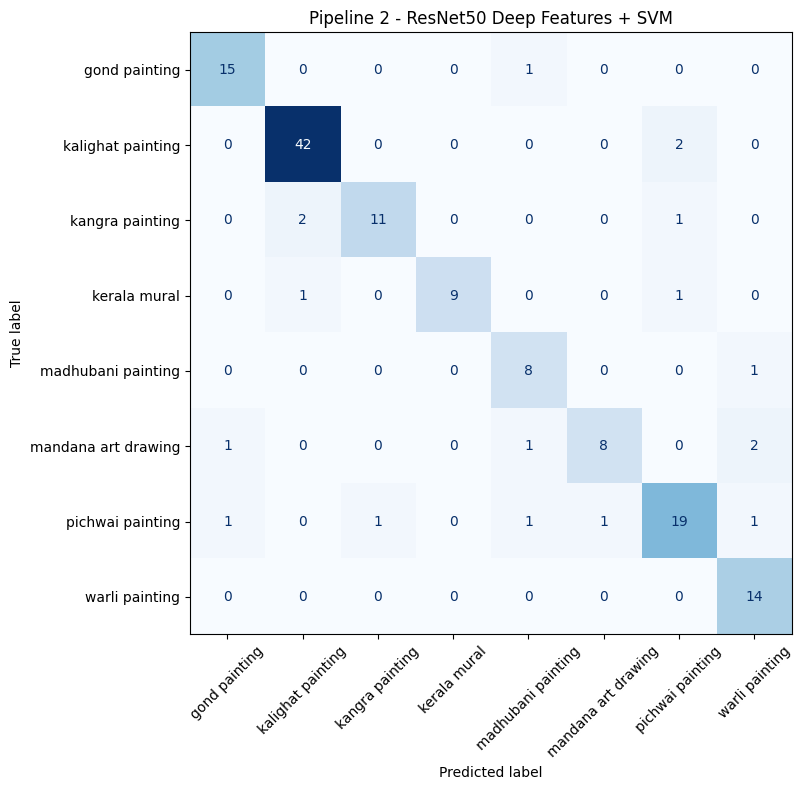

In [ ]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_test_pred,
    labels=np.arange(len(class_names))
)

print("Confusion Matrix:")
print(cm)

fig, ax = plt.subplots(
    figsize=(10, 8)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues",
    colorbar=False
)

plt.title(
    "Pipeline 2 - ResNet50 Deep Features + SVM"
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# FINAL RESULTS SUMMARY
# ============================================================

final_results = {
    "pipeline": "CNN Deep Features + SVM",
    "feature_extractor": "Fine-tuned ResNet50",
    "feature_dimension": FEATURE_DIM,
    "classifier": "SVM",
    "kernel": best_params["kernel"],
    "C": best_params["C"],
    "gamma": best_params["gamma"],
    "split": "70/15/15",
    "random_seed": SEED,
    "num_classes": len(class_names),
    "train_samples": len(train_subset),
    "validation_samples": len(val_subset),
    "test_samples": len(test_subset),
    "validation_macro_f1": float(best_macro_f1),
    "test_accuracy": float(test_accuracy),
    "test_macro_precision": float(test_macro_precision),
    "test_macro_recall": float(test_macro_recall),
    "test_macro_f1": float(test_macro_f1),
    "test_weighted_f1": float(test_weighted_f1)
}

print("========== PIPELINE 2 FINAL SUMMARY ==========")

for key, value in final_results.items():
    print(f"{key}: {value}")

========== PIPELINE 2 FINAL SUMMARY ==========
pipeline: CNN Deep Features + SVM
feature_extractor: Fine-tuned ResNet50
feature_dimension: 2048
classifier: SVM
kernel: linear
C: 0.1
gamma: None
split: 70/15/15
random_seed: 42
num_classes: 8
train_samples: 667
validation_samples: 142
test_samples: 144
validation_macro_f1: 0.8137781151596941
test_accuracy: 0.875
test_macro_precision: 0.8690474114547004
test_macro_recall: 0.8553954725829725
test_macro_f1: 0.8555600475208113
test_weighted_f1: 0.8737278523698258


##Preserve work

In [ ]:
# ============================================================
# SAVE FINAL SVM ARTIFACTS
# ============================================================

svm_artifact = {
    "scaler": final_scaler,
    "svm": final_svm,
    "class_names": class_names,
    "class_to_idx": class_to_idx,
    "feature_dimension": FEATURE_DIM,
    "best_params": best_params,
    "seed": SEED,
    "split": {
        "train": 0.70,
        "validation": 0.15,
        "test": 0.15
    }
}

joblib.dump(
    svm_artifact,
    "pipeline2_resnet50_svm_final.joblib"
)

with open(
    "pipeline2_final_results.json",
    "w"
) as f:
    json.dump(
        final_results,
        f,
        indent=4
    )

svm_results_df.to_csv(
    "pipeline2_svm_validation_results.csv",
    index=False
)

classification_report_df.to_csv(
    "pipeline2_classification_report.csv"
)

print("Saved:")
print("1. pipeline2_resnet50_svm_final.joblib")
print("2. pipeline2_final_results.json")
print("3. pipeline2_svm_validation_results.csv")
print("4. pipeline2_classification_report.csv")

Saved:
1. pipeline2_resnet50_svm_final.joblib
2. pipeline2_final_results.json
3. pipeline2_svm_validation_results.csv
4. pipeline2_classification_report.csv


In [ ]:
import shutil

DRIVE_FOLDER = "/content/drive/MyDrive/Iconography/Implementation/SVM+ResNet"

# Create folder if it does not already exist
os.makedirs(DRIVE_FOLDER, exist_ok=True)

print("Saving Pipeline 2 artifacts to:")
print(DRIVE_FOLDER)

# ------------------------------------------------------------
# Files generated by Pipeline 2
# ------------------------------------------------------------

files_to_save = [
    "pipeline2_resnet50_svm_final.joblib",
    "pipeline2_final_results.json",
    "pipeline2_svm_validation_results.csv",
    "pipeline2_classification_report.csv",
    "pipeline2_resnet50_features.npz"
]

# ------------------------------------------------------------
# Copy files to Google Drive
# ------------------------------------------------------------

saved_files = []

for filename in files_to_save:

    source_path = os.path.join(
        "/content",
        filename
    )

    if os.path.exists(source_path):

        destination_path = os.path.join(
            DRIVE_FOLDER,
            filename
        )

        shutil.copy2(
            source_path,
            destination_path
        )

        saved_files.append(destination_path)

        print(f"✓ Saved: {filename}")

    else:
        print(f"⚠ Not found: {filename}")

# ------------------------------------------------------------
# Final verification
# ------------------------------------------------------------

print("\n========== SAVE VERIFICATION ==========")

for filepath in saved_files:

    if os.path.exists(filepath):

        size_mb = os.path.getsize(filepath) / (1024 ** 2)

        print(
            f"✓ {os.path.basename(filepath)} "
            f"({size_mb:.2f} MB)"
        )

    else:
        print(
            f"✗ FAILED: {os.path.basename(filepath)}"
        )

print("\nPipeline 2 artifacts saved successfully.")

Saving Pipeline 2 artifacts to:
/content/drive/MyDrive/Iconography/Implementation/SVM+ResNet
✓ Saved: pipeline2_resnet50_svm_final.joblib
✓ Saved: pipeline2_final_results.json
✓ Saved: pipeline2_svm_validation_results.csv
✓ Saved: pipeline2_classification_report.csv
⚠ Not found: pipeline2_resnet50_features.npz

========== SAVE VERIFICATION ==========
✓ pipeline2_resnet50_svm_final.joblib (9.03 MB)
✓ pipeline2_final_results.json (0.00 MB)
✓ pipeline2_svm_validation_results.csv (0.00 MB)
✓ pipeline2_classification_report.csv (0.00 MB)

Pipeline 2 artifacts saved successfully.
